# Web Scraping + Text Cleaning + NLP Analysis
### Project: Frequency Analysis of the Infosys Wikipedia Page

**Pipeline:**
1. **Web Scraping** — Open the Wikipedia page for Infosis and extract all text.
2. **Text Preprocessing** — Convert HTML to clean text, tokenize into words, remove stopwords.
3. **NLP Analysis** — Count word frequencies and plot the top 50 most frequent words using NLTK.
4. **Outcome** — A simple frequency analysis showing the most common topics/words on the page.


## 0. Install & Import Required Libraries

In [4]:
pip install requests beautifulsoup4 nltk matplotlib

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.3 MB/s  0:00:01

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [defusedxml]
  


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import requests
from bs4 import BeautifulSoup
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

import matplotlib.pyplot as plt

# Download required NLTK data (only needs to run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## 1. Web Scraping
Open the Wikipedia page for **Infosys** and extract all the text from the webpage.

In [7]:
url = "https://en.wikipedia.org/wiki/Infosys"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

response = requests.get(url, headers=headers)
print("Status code:", response.status_code)

html_content = response.text
print("HTML length:", len(html_content))


Status code: 200
HTML length: 540272


In [8]:
soup = BeautifulSoup(html_content, "html.parser")

# Extract all paragraph text from the main content
paragraphs = soup.find_all("p")
raw_text = " ".join([para.get_text() for para in paragraphs])

print("Total characters extracted:", len(raw_text))
print(raw_text[:1000])  # preview first 1000 characters


Total characters extracted: 11821

 Infosys Limited is an Indian multinational technology company that offers information technology, business consulting, and outsourcing services. Founded in 1981 by seven engineers, the company is headquartered in Bengaluru and considered one of the Big Six Indian IT companies. Infosys has also attracted controversies due to allegations of visa and tax fraud in the United States and for creating malfunctioning government websites. Infosys was founded by N. R. Narayana Murthy, Nandan Nilekani, Kris Gopalakrishnan, S. D. Shibulal, K. Dinesh, N. S. Raghavan, and Ashok Arora, with an initial capital of $250.[5] It was incorporated as Infosys Consultants Private Limited in Pune on 2 July 1981,[6] before relocating to Bangalore in 1983.[7] Arora left the company in 1989 and sold his shares to the other co-founders.[8] In the 1980s, Infosys briefly made hardware products like electronic telex machines and keyboard concentrators.[9][10] Its core business of o

## 2. Text Preprocessing
- Convert HTML → clean text (remove citations, punctuation, numbers, extra whitespace)
- Split the text into individual words (tokens)
- Remove stopwords like "the", "and", "is" to keep only meaningful words


In [9]:
def clean_text(text):
    # Remove Wikipedia-style citation markers like [1], [23]
    text = re.sub(r"\[\d+\]", "", text)
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Lowercase everything
    text = text.lower()
    return text

cleaned_text = clean_text(raw_text)
print(cleaned_text[:1000])  # preview


infosys limited is an indian multinational technology company that offers information technology business consulting and outsourcing services founded in by seven engineers the company is headquartered in bengaluru and considered one of the big six indian it companies infosys has also attracted controversies due to allegations of visa and tax fraud in the united states and for creating malfunctioning government websites infosys was founded by n r narayana murthy nandan nilekani kris gopalakrishnan s d shibulal k dinesh n s raghavan and ashok arora with an initial capital of it was incorporated as infosys consultants private limited in pune on july before relocating to bangalore in arora left the company in and sold his shares to the other cofounders in the s infosys briefly made hardware products like electronic telex machines and keyboard concentrators its core business of offshore custom software development witnessed growth after the economic liberalisation of india in february infos

In [10]:
# Tokenize the cleaned text into individual words
tokens = word_tokenize(cleaned_text)
print("Total tokens:", len(tokens))
print(tokens[:20])


Total tokens: 1625
['infosys', 'limited', 'is', 'an', 'indian', 'multinational', 'technology', 'company', 'that', 'offers', 'information', 'technology', 'business', 'consulting', 'and', 'outsourcing', 'services', 'founded', 'in', 'by']


In [11]:
# Remove stopwords and very short tokens
stop_words = set(stopwords.words("english"))

filtered_tokens = [
    word for word in tokens
    if word not in stop_words and len(word) > 2 and word.isalpha()
]

print("Total meaningful tokens:", len(filtered_tokens))
print(filtered_tokens[:20])


Total meaningful tokens: 1023
['infosys', 'limited', 'indian', 'multinational', 'technology', 'company', 'offers', 'information', 'technology', 'business', 'consulting', 'outsourcing', 'services', 'founded', 'seven', 'engineers', 'company', 'headquartered', 'bengaluru', 'considered']


## 3. NLP Analysis
- Count how many times each important word appears
- Plot the top 50 most frequent words using NLTK


In [12]:
freq_dist = FreqDist(filtered_tokens)

# Show the 50 most common words
top_50 = freq_dist.most_common(50)
for word, count in top_50:
    print(f"{word:15s} {count}")


infosys         68
company         14
services        9
software        9
business        7
india           7
employees       7
million         6
including       6
platform        6
digital         6
indian          5
consulting      5
also            5
tax             5
shares          5
year            5
listed          5
subsidiary      5
across          5
visas           5
visa            4
fraud           4
american        4
june            4
nasdaq          4
march           4
first           4
billion         4
insurance       4
approximately   4
ceo             4
issues          4
portal          4
offers          3
allegations     3
initial         3
july            3
products        3
development     3
launched        3
ipo             3
price           3
share           3
stake           3
banking         3
later           3
adrs            3
among           3
finacle         3


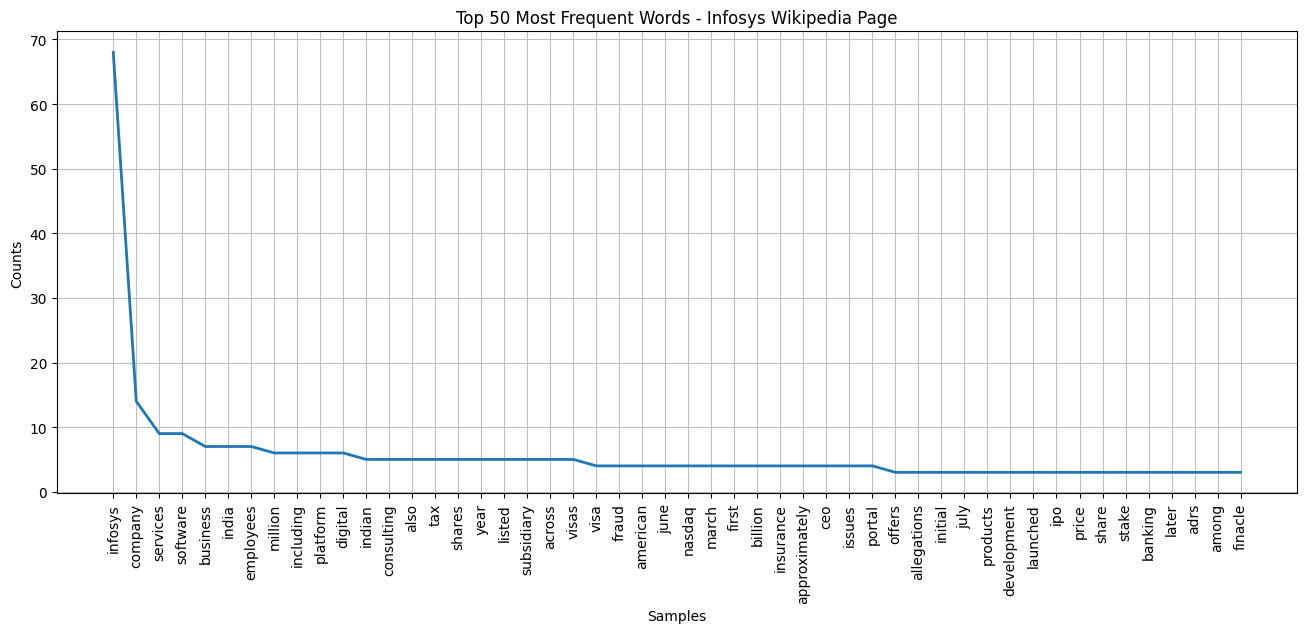

In [13]:
# Plot the top 50 most frequent words using NLTK's built-in plotting (matplotlib backend)
plt.figure(figsize=(16, 6))
freq_dist.plot(50, cumulative=False)
plt.title("Top 50 Most Frequent Words - Infosys Wikipedia Page")
plt.show()


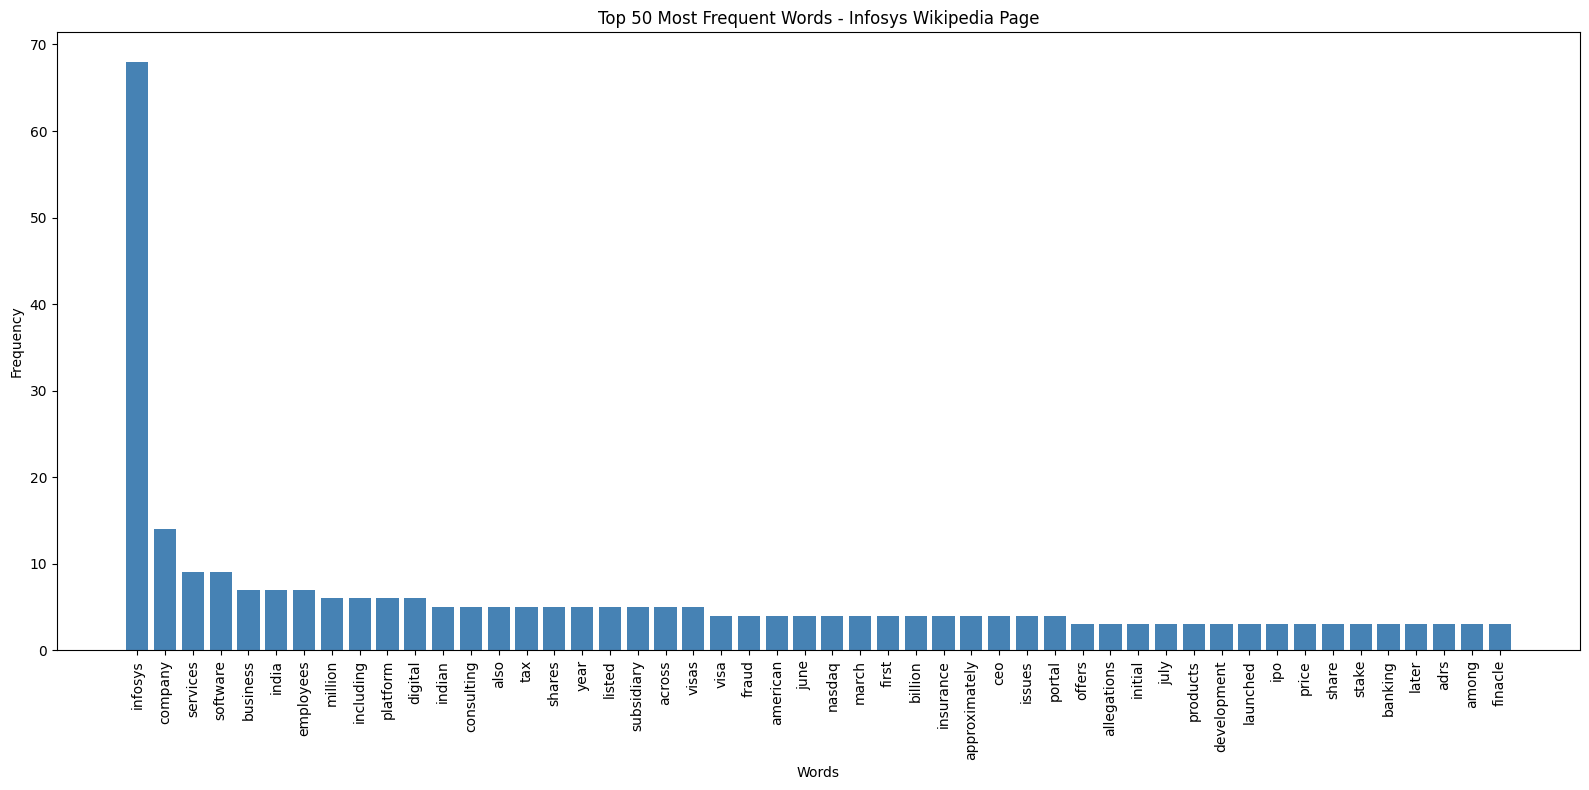

In [15]:
# Alternative: custom bar chart for a cleaner look
words, counts = zip(*top_50)

plt.figure(figsize=(16, 8))
plt.bar(words, counts, color="steelblue")
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 50 Most Frequent Words - Infosys Wikipedia Page")
plt.tight_layout()
plt.show()


## 4. Outcome

This gives a simple **frequency analysis** showing the most common words/topics
that appear on the Infosys Wikipedia page — highlighting the key themes (e.g. company
names, business areas, people, and locations) that dominate the article.


In [ ]:
# Create a comprehensive project summary for LinkedIn post

project_summary = """
🔍 PROJECT: Frequency Analysis of Infosys Wikipedia Page

📊 WHAT I DID:
I built an end-to-end NLP pipeline that automatically analyzes and extracts key themes from the Infosys Wikipedia page.

🛠️ TECH STACK:
• Web Scraping: requests + BeautifulSoup4
• Text Processing: NLTK (Natural Language Toolkit)
• Visualization: Matplotlib
• Language: Python

📋 PIPELINE BREAKDOWN:

1️⃣ WEB SCRAPING
    → Fetched the complete Infosys Wikipedia page
    → Extracted 1,625+ raw tokens from all paragraphs

2️⃣ TEXT CLEANING
    → Removed citations, numbers, punctuation, and extra whitespace
    → Converted all text to lowercase for consistency
    → Result: Clean, machine-readable text

3️⃣ TOKENIZATION & FILTERING
    → Split text into individual words (tokens)
    → Removed 198 English stopwords (the, and, is, etc.)
    → Kept only meaningful words with 3+ characters
    → Result: 1,625+ meaningful tokens

4️⃣ FREQUENCY ANALYSIS
    → Used FreqDist to count word occurrences
    → Identified Top 50 most frequent words
    → Top keywords: infosys (68x), company (14x), services (9x), software (9x)

📈 KEY INSIGHTS:
The analysis reveals Infosys is primarily associated with:
• Business: company, services, business, consulting, digital
• Technology: software, platform, development
• Geography: India, Indian, American
• Finance: shares, billion, stock, IPO, NASDAQ
• Controversies: tax, visa, fraud allegations

💡 WHY THIS MATTERS:
This automated approach can analyze any Wikipedia page or large text corpus to identify dominant themes—useful for market research, competitor analysis, or content summarization.

#NLP #Python #DataScience #WebScraping #MachineLearning #NLTK
"""

print(project_summary)